### Importing required modules and libraries

In [70]:
# I/O & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import itables

# Pre-processing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handle imbalance data
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Seaborn professional style
sns.set_style("whitegrid")

## 1. Data Ingestion

Connecting to huggingface through GUI

**Note : Only run this once to autenticate the connection to huggingface**

In [71]:
# from huggingface_hub import login
# login()

In [72]:
# Importing the parquet dataset
from huggingface_hub import HfFileSystem

fs = HfFileSystem()

with fs.open("datasets/analytical-community/airline_fraud_transactions/airline_fraud_3M.parquet", "rb") as f:
    df_raw = pd.read_parquet(f, engine="pyarrow")

print(f"The shape of this dataset is: {df_raw.shape}")

The shape of this dataset is: (3000000, 23)


In [73]:
# Previewing the dataset
print(df_raw.head())

     transaction_date          payment_id           mrn     pnr  \
0 2025-12-01 00:00:04  SS0TXIY6Z4X8N2MQCD  SS0TXIY6Z4X8  SS0TXI   
1 2025-12-01 00:00:21  XNZB8J4KGUDUOSJ5GP  XNZB8J4KGUDU  XNZB8J   
2 2025-12-01 00:00:21  FTYM8EA6BOGOMFVLB5  FTYM8EA6BOGO  FTYM8E   
3 2025-12-01 00:00:35  9XVTFC5UNP7NZ7RDI0  9XVTFC5UNP7N  9XVTFC   
4 2025-12-01 00:00:37  JI4WCFOWYHP3PYHW73  JI4WCFOWYHP3  JI4WCF   

                    email_address      ip_address  \
0  charlesjohnson4582@outlook.com   18.120.165.55   
1   jordanlewis5641@umbrella.corp  248.32.174.241   
2    martinpatricia9228@yahoo.com  142.136.236.68   
3       charles.lopez@outlook.com    85.143.68.25   
4        elizabethwhite@yahoo.com   36.185.224.95   

                          device_id    route   amount  amount_in_usd  ...  \
0  1789e9872f53419e8efbca8949b64ba8  SIN-ATL   771.18         771.18  ...   
1  f74cf5ff4f427e7a310abd82a2a85c46  BCN-FRA   250.36         250.36  ...   
2  dbba5bb6cebf3de2f37f3ecf1a932425  CJU-SUB   

In [74]:
# Checking data types
print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 23 columns):
 #   Column                Dtype         
---  ------                -----         
 0   transaction_date      datetime64[us]
 1   payment_id            str           
 2   mrn                   str           
 3   pnr                   str           
 4   email_address         str           
 5   ip_address            str           
 6   device_id             str           
 7   route                 str           
 8   amount                float64       
 9   amount_in_usd         float64       
 10  currency              str           
 11  card_type             str           
 12  card_bin              str           
 13  card_last_4           str           
 14  bank_name             str           
 15  bin_country           str           
 16  loyalty_tier          str           
 17  txn_origin_country    str           
 18  account_age_days      int64         
 19  failed_atte

In [75]:
print(df_raw.describe().round(2))

                 transaction_date      amount  amount_in_usd  \
count                     3000000  3000000.00     3000000.00   
mean   2026-02-28 23:34:08.459755      942.61         816.85   
min           2025-12-01 00:00:04        1.00           0.01   
25%    2026-01-15 00:09:48.750000      418.27         225.54   
50%    2026-02-28 22:37:58.500000      771.45         635.04   
75%           2026-04-15 01:30:17     1258.77        1163.23   
max           2026-05-29 23:59:57    20869.22       23377.71   
std                           NaN      752.45         808.34   

       account_age_days  failed_attempts    is_fraud  session_time_seconds  
count        3000000.00       3000000.00  3000000.00            3000000.00  
mean             359.58             0.10        0.02                622.09  
min                0.00             0.00        0.00                 45.00  
25%              173.00             0.00        0.00                333.00  
50%              302.00             0.

In [76]:
# Checking for NaN/Null values
print(df_raw.isna().sum())

transaction_date        0
payment_id              0
mrn                     0
pnr                     0
email_address           0
ip_address              0
device_id               0
route                   0
amount                  0
amount_in_usd           0
currency                0
card_type               0
card_bin                0
card_last_4             0
bank_name               0
bin_country             0
loyalty_tier            0
txn_origin_country      0
account_age_days        0
failed_attempts         0
is_fraud                0
billing_country         0
session_time_seconds    0
dtype: int64


In [77]:
# Making a copy of the original raw dataset
df = df_raw.copy()

## Exploratory Data Analysis

In [78]:
# Checking the ratio of fraud vs non-fraud distribution
df.is_fraud.value_counts(normalize=True)*100

is_fraud
0    98.5
1     1.5
Name: proportion, dtype: float64

The dataset has an overall fraud rate of 1.5%

Downsampling the data to avoid kernal crash as aggregating the 'amount' column is very resource intensive 

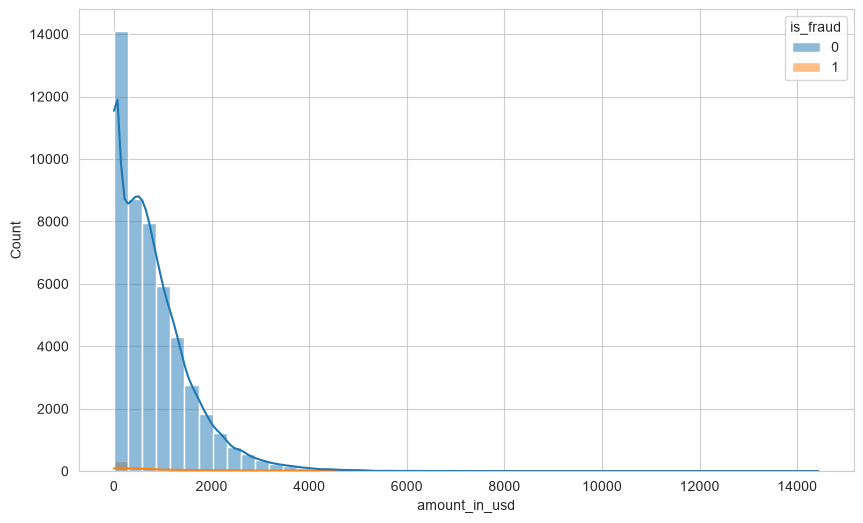

In [79]:
# Strategic Downsampling
# Taking a random sample of 50,000 rows to protect system memory or avoid kernal crash
df_sample = df.sample(n=50000, random_state=22)

# Plotting the cleaned, normalized distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_sample, 
    x='amount_in_usd',
    hue='is_fraud', 
    kde=True, 
    bins=50
)

plt.show()

### Calculating actual revenue loss after normalizing the currencies

In [80]:
total_txn_amt = df['amount_in_usd'].sum()
print(f"Sum of total transaction amount in USD: {total_txn_amt:,.2f}")
fraud_total_amt = df.query("is_fraud == 1")['amount_in_usd'].sum()
print(f"Sum of total fraud amount in USD: {fraud_total_amt:,.2f}")

fraud_perc_amt = fraud_total_amt * 100 / total_txn_amt
print(f"Percentage of revenue loss: {fraud_perc_amt:,.2f}%")

Sum of total transaction amount in USD: 2,450,547,115.99
Sum of total fraud amount in USD: 55,203,945.03
Percentage of revenue loss: 2.25%


### Categorical Risk Profiles

In [81]:
# Aggregate the counts and sums
risk_profile = df.groupby(['card_type', 'bin_country', 'bank_name']).agg(
    total_transactions=('is_fraud', 'count'),    # Total number of rows
    fraud_transactions=('is_fraud', 'sum')       # Total number of 1s
).reset_index()

# Calculate the fraud rate manually
risk_profile['fraud_rate'] = (risk_profile['fraud_transactions'] / risk_profile['total_transactions']).round(3)

# Sort to find the most dangerous combinations at the top
risk_profile = risk_profile.sort_values(by='fraud_rate', ascending=False)

# Let's peek at the top 10 riskiest combinations
print(risk_profile.head(10))

     card_type bin_country    bank_name  total_transactions  \
11  MasterCard          IN         HDFC               59626   
0         Amex          ES    Santander               30137   
2         Amex          GB         HSBC               30189   
1         Amex          GB     Barclays               29867   
5         Amex          US        Chase               60204   
7         Amex          US  Wells Fargo               59663   
9   MasterCard          GB     Barclays              119655   
3         Amex          IN         HDFC               15091   
22        Visa          US         Citi              299769   
17        Visa          GB     Barclays              149417   

    fraud_transactions  fraud_rate  
11                 930       0.016  
0                  443       0.015  
2                  448       0.015  
1                  445       0.015  
5                  907       0.015  
7                  877       0.015  
9                 1803       0.015  
3         

### Checking for fraud spikes during odd hours

In [82]:
# Extracting the hour from date column
df['transaction_hour'] = df['transaction_date'].dt.hour

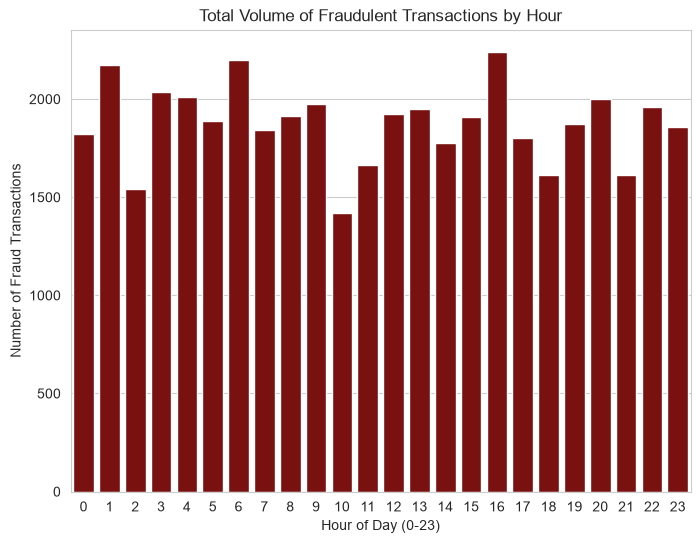

In [83]:
plt.figure(figsize=(8,6))

fraud_txns = df[df['is_fraud'] == 1]

sns.countplot(
    x='transaction_hour',
    data=fraud_txns,
    color='darkred'
)

plt.title('Total Volume of Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Fraud Transactions')
plt.show()

Observation: No unusual spikes are visible during odd or midnight hours

## Feature Engineering

In [125]:
df_copy.columns

Index(['transaction_date', 'payment_id', 'mrn', 'pnr', 'email_address',
       'ip_address', 'device_id', 'route', 'amount', 'amount_in_usd',
       'currency', 'card_type', 'card_bin', 'card_last_4', 'bank_name',
       'bin_country', 'loyalty_tier', 'txn_origin_country', 'account_age_days',
       'failed_attempts', 'is_fraud', 'billing_country',
       'session_time_seconds', 'transaction_hour', 'temp_id',
       'device_id_last_24h', 'total_cards_ip_7d', 'country_mismatch'],
      dtype='str')

In [134]:
itables.show(df_copy)

Loading ITables v2.8.1 from the internet... (need help?)


In [121]:
df_copy = df.copy()


Feature 1: Transaction count from `device_id` in Last 24hrs

In [ ]:
# Sorting the date chronologically
df_copy = df_copy.sort_values('transaction_date').reset_index(drop=True)

#Set index temporarily
df_copy = df_copy.set_index('transaction_date')

# Run the rolling count
rolling_output = (
    df_copy.groupby('device_id')['payment_id']
    .rolling('24h')
    .count()
)

# Create a new column of total count of txn in a 24 hr from each device id
df_copy['device_id_last_24h'] = rolling_output.values

# Bring transaction_date back as a standard column
df_copy = df_copy.reset_index()

Feature 2: Card count from `ip_address` in 7 days

In [ ]:
df_copy = df_copy.sort_values('transaction_date').reset_index(drop=True)

df_copy = df_copy.set_index('transaction_date')

rolling_out = ( df_copy.groupby('ip_address')['card_bin']
               .rolling('7d')
               .apply(lambda x: len(np.unique(x)), raw=True)
) 

df_copy['total_cards_ip_7d'] = rolling_out.values


df_copy = df_copy.reset_index()

Feature 3: Country Mismatch ~ Bin country vs Txn origin country~

In [124]:
df_copy['country_mismatch'] = np.where(df_copy['bin_country'] != df_copy['txn_origin_country'],1,0)

Feature 4: Categorizing risk score as per `Email Domain usage`

In [126]:
df_copy['email_domain'] = df_copy['email_address'].str.split('@').str[1]

In [129]:
domain_counts = df_copy['email_domain'].value_counts()

df_copy['domain_txn_vol'] = df_copy['email_domain'].map(domain_counts)

conditions = [df_copy['domain_txn_vol'] > 60000, (df_copy['domain_txn_vol'] >= 40000) & (df_copy['domain_txn_vol'] <= 55000)]

choices = [0,1]
df_copy['domain_risk_score'] = np.select(conditions, choices,default=2)

df_copy = df_copy.drop(columns=['domain_txn_vol'])


Feature 4: Categorizing Risk score based on `account_age_days`

In [135]:
bins = [-1, 0 ,30, np.inf]

label = ['New < 1 day', '1-30 days', '> 30 days']

df_copy['account_age_group'] = pd.cut(df_copy['account_age_days'], bins=bins, labels=label)

risk_labels = [2, 1, 0]

df_copy['account_age_risk_score'] = pd.cut(df_copy['account_age_days'], bins=bins, labels=risk_labels).astype(int)
